In [2]:
%load_ext autoreload
%autoreload 2

Params

---
1k

GMP: "gmp_degree": 6

LSTM: "hidden_size": 15, 
    "num_layers": 1,
    "bidirectional": False,

GRU: "hidden_size": 16, 
    "num_layers": 1,
    "bidirectional": False,

RTDTNN: "M": 6,
        "P": 6,
        "d_in": P+2,
        "d_model": 10,
        "n_heads": 2,
        "d_ff": 10,
        "n_fc": 2,

LEANN:  "M": 6,
        "L1": 16,
        "L2": 8,
        "L3": 16,
        "K": 3,

PLEANN: "M": M,
        "L1": 16,
        "L2": 8,
        "L3": 16,
        "K": 3,
        "lr": 0.001,
        "lr2": 0.0001,
        "epochs": 300,
        "epochs2": 200,
        "lambda_reg": 1e-3,
        "alpha": 0.003,
        "tau": 0.002,

---

2k

GMP: "gmp_degree": 8

LSTM:

GRU:

RTDTNN:

LEANN:

PLEANN

TCN:

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from modules import data_loader, metrics, plotting, utils, params, learning, prunning
from models.gmp import GMP
from models.gru import GRU, KPGRU
from models.lstm import LSTM, KPLSTM
from models.rtdtnn import RTDTNN
from models.leann import LEANN
from models.tcn import TCN, KPTCN
from modules.pipelines import SimplePipeline


Load data from files and init acpr meter

In [4]:
M = 5
P = 3

container = data_loader.DataContainer()
container.load_data(file_path="datasets/Custom_dataset")
container.cut_signals(M=M)
container.get_gained_signals()


acpr_meter = metrics.ACPR(
        sample_rate=container.input_signal_fs,
        main_measurement_bandwidth=container.bw_main_ch,
        adjacent_channel_offset=[-container.sub_ch, container.sub_ch],
        segment_length=container.nperseg,
        overlap_percentage=60,
        window='blackmanharris',
        fft_length=container.nperseg,
        power_units='dBW',
        return_main_power=True,
        return_adjacent_powers=True
    )


PA MODEL

In [5]:
gmp_train_props = {
    "gmp_degree": 6,
    "lr": 0.001,
    "epochs": 200,
    "acpr_meter": acpr_meter
}

pa_gmp_pipeline = SimplePipeline(container=container, 
                                 train_props=gmp_train_props, 
                                 base_model=GMP)

pa_gmp_pipeline.run_pa()
pa_model = pa_gmp_pipeline.get_pa_model()

pa_results = pa_gmp_pipeline.get_results()

gmp_pa_nmse = pa_results["pa"]["nmse"]
pa_acpr = pa_results["pa"]["acpr"]
y_val_pa = pa_results["pa"]["y_val_pa_model"]


Run PA
count_params: 936
count_flops: 5652
Model weights loaded from model_params/pa_GMP_Ka6_La6_Kb6_Lb6_Mb6_Kc6_Lc6_Mc6.pt
[PA] NMSE: -40.75, ACPR: -41.20 -40.75


GMP

In [12]:
gmp_train_props = {
    "gmp_degree": 8,
    "lr": 0.01,
    "epochs": 200,
    "acpr_meter": acpr_meter
}

gmp_pipeline = SimplePipeline(container=container, 
                              train_props=gmp_train_props, 
                              base_model=GMP,
                              pa_model=pa_model)


In [ ]:

gmp_stats = gmp_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

gmp_agg_stats = metrics.summarize_statistics(gmp_stats)

gmp_results = gmp_pipeline.get_results()

gmp_count = gmp_results["ilc"]["count_params"]

final_gmp_stats = {
        "Model": "GMP",
        "Params": gmp_count,
        "FLOPs": gmp_results["ilc"]["count_flops"],
        "NMSE (dB)": round(gmp_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(gmp_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(gmp_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_gmp_stats)


=== Run 1/5 ===
Run ILC
count_params: 2176
Epoch [0/200], Loss: 0.004443641286343336
Epoch [100/200], Loss: 8.294723130575221e-08
Epoch [199/200], Loss: 2.2939243837782897e-09
Выполнение заняло: 0:01:55
Epoch [0/200], Loss: 0.004412407521158457
Epoch [100/200], Loss: 8.252550998122388e-08
Epoch [199/200], Loss: 5.0308555064881855e-12
Выполнение заняло: 0:00:27
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.00001231, val_loss: 0.00000021, val_NMSE: -31.96, lr: 0.01
Epoch 0001 — train_loss: 0.00000041, val_loss: 0.00000014, val_NMSE: -33.77, lr: 0.01
Epoch 0002 — train_loss: 0.00000072, val_loss: 0.00000027, val_NMSE: -30.88, lr: 0.01
Epoch 0003 — train_loss: 0.00000090, val_loss: 0.00000007, val_NMSE: -36.62, lr: 0.01
Epoch 0004 — train_loss: 0.00000084, val_loss: 0.00000009, val_NMSE: -35.72, lr: 0.01
Epoch 0005 — train_loss: 0.00000143, val_loss: 0.00000008, val_NMSE: -36.41, lr: 0.01
Epoch 0006 — train_loss: 0.00000093, val_loss: 0.00000045, v

KPGRU

In [14]:

kpgru_train_props = {
    "M": M,
    "hidden_size": 10,
    "num_layers": 1,
    "bidirectional": False,
    "reduced_dim": 8,
    "lr": 0.01,
    "epochs": 300,
    "acpr_meter": acpr_meter,
}

kpgru_pipeline = SimplePipeline(container=container, 
                              train_props=kpgru_train_props, 
                              base_model=KPGRU,
                              pa_model=pa_model)


In [ ]:

kpgru_stats = kpgru_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

kpgru_agg_stats = metrics.summarize_statistics(kpgru_stats)

kpgru_results = kpgru_pipeline.get_results()

kpgru_count = kpgru_results["ilc"]["count_params"]

final_kpgru_stats = {
        "Model": "KPGRU",
        "Params": kpgru_count,
        "FLOPs": kpgru_results["ilc"]["count_flops"],
        "NMSE (dB)": round(kpgru_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(kpgru_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(kpgru_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_kpgru_stats)


=== Run 1/5 ===
Run ILC
count_params: 2046
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.03085936, val_loss: 0.00117567, val_NMSE: -28.73, lr: 0.01
Epoch 0001 — train_loss: 0.00120833, val_loss: 0.00039293, val_NMSE: -33.49, lr: 0.01
Epoch 0002 — train_loss: 0.00074243, val_loss: 0.00026704, val_NMSE: -35.17, lr: 0.01
Epoch 0003 — train_loss: 0.00057281, val_loss: 0.00019461, val_NMSE: -36.54, lr: 0.01
Epoch 0004 — train_loss: 0.00049054, val_loss: 0.00013287, val_NMSE: -38.20, lr: 0.01
Epoch 0005 — train_loss: 0.00043155, val_loss: 0.00023293, val_NMSE: -35.76, lr: 0.01
Epoch 0006 — train_loss: 0.00037423, val_loss: 0.00019775, val_NMSE: -36.47, lr: 0.01
Epoch 0007 — train_loss: 0.00036811, val_loss: 0.00010323, val_NMSE: -39.30, lr: 0.01
Epoch 0008 — train_loss: 0.00030815, val_loss: 0.00009508, val_NMSE: -39.65, lr: 0.01
Epoch 0009 — train_loss: 0.00028992, val_loss: 0.00010167, val_NMSE: -39.36, lr: 0.01
Epoch 0010 — train_loss: 0.00026438,

KPLSTM

In [26]:

kplstm_train_props = {
    "M": M,
    "hidden_size": 8,
    "num_layers": 1,
    "reduced_dim": 8,
    "bidirectional": False,
    "lr": 0.01,
    "epochs": 300,
    "acpr_meter": acpr_meter,
}

kplstm_pipeline = SimplePipeline(container=container, 
                              train_props=kplstm_train_props, 
                              base_model=KPLSTM,
                              pa_model=pa_model)


In [ ]:

kplstm_stats = kplstm_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

kplstm_agg_stats = metrics.summarize_statistics(kplstm_stats)

kplstm_results = kplstm_pipeline.get_results()

kplstm_count = kplstm_results["ilc"]["count_params"]

final_kplstm_stats = {
        "Model": "KPLSTM",
        "Params": kplstm_count,
        "FLOPs": kplstm_results["ilc"]["count_flops"],
        "NMSE (dB)": round(kplstm_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(kplstm_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(kplstm_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_kplstm_stats)


=== Run 1/5 ===
Run ILC
count_params: 2018
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.05240492, val_loss: 0.00215148, val_NMSE: -26.11, lr: 0.01
Epoch 0001 — train_loss: 0.00251719, val_loss: 0.00097686, val_NMSE: -29.54, lr: 0.01
Epoch 0002 — train_loss: 0.00142079, val_loss: 0.00052916, val_NMSE: -32.20, lr: 0.01
Epoch 0003 — train_loss: 0.00098797, val_loss: 0.00036445, val_NMSE: -33.82, lr: 0.01
Epoch 0004 — train_loss: 0.00078399, val_loss: 0.00027927, val_NMSE: -34.97, lr: 0.01
Epoch 0005 — train_loss: 0.00064773, val_loss: 0.00029365, val_NMSE: -34.76, lr: 0.01
Epoch 0006 — train_loss: 0.00054699, val_loss: 0.00046678, val_NMSE: -32.74, lr: 0.01
Epoch 0007 — train_loss: 0.00052707, val_loss: 0.00023009, val_NMSE: -35.81, lr: 0.01
Epoch 0008 — train_loss: 0.00045298, val_loss: 0.00016338, val_NMSE: -37.30, lr: 0.01
Epoch 0009 — train_loss: 0.00042687, val_loss: 0.00015876, val_NMSE: -37.43, lr: 0.01
Epoch 0010 — train_loss: 0.00039888,

KPTCN

In [5]:

kptcn_train_props = {
    "M": M,
    "hidden_channels": 22,
    "kernel_size": 4,
    "reduced_dim": 8,
    "lr": 0.01,
    "epochs": 300,
    "acpr_meter": acpr_meter,
}

kptcn_pipeline = SimplePipeline(container=container, 
                              train_props=kptcn_train_props, 
                              base_model=KPTCN,
                              pa_model=pa_model)


In [ ]:

kptcn_stats = kptcn_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

kptcn_agg_stats = metrics.summarize_statistics(kptcn_stats)

kptcn_results = kptcn_pipeline.get_results()

kptcn_count = kptcn_results["ilc"]["count_params"]

final_kptcn_stats = {
        "Model": "KPTCN",
        "Params": kptcn_count,
        "FLOPs": kptcn_results["ilc"]["count_flops"],
        "NMSE (dB)": round(kptcn_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(kptcn_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(kptcn_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_kptcn_stats)


=== Run 1/5 ===
Run ILC
count_params: 2036
Epoch [0/200], Loss: 0.004443641286343336
Epoch [100/200], Loss: 8.294723130575221e-08
Epoch [199/200], Loss: 2.2939243837782897e-09
Выполнение заняло: 0:02:18
Epoch [0/200], Loss: 0.004412407521158457
Epoch [100/200], Loss: 8.252550998122388e-08
Epoch [199/200], Loss: 5.0308555064881855e-12
Выполнение заняло: 0:00:26
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.12233300, val_loss: 0.00036203, val_NMSE: -33.85, lr: 0.01
Epoch 0001 — train_loss: 0.00075551, val_loss: 0.00028219, val_NMSE: -34.93, lr: 0.01
Epoch 0002 — train_loss: 0.00051836, val_loss: 0.00015332, val_NMSE: -37.58, lr: 0.01
Epoch 0003 — train_loss: 0.00042295, val_loss: 0.00012566, val_NMSE: -38.44, lr: 0.01
Epoch 0004 — train_loss: 0.00035117, val_loss: 0.00007298, val_NMSE: -40.80, lr: 0.01
Epoch 0005 — train_loss: 0.00030633, val_loss: 0.00008038, val_NMSE: -40.38, lr: 0.01
Epoch 0006 — train_loss: 0.00026395, val_loss: 0.00007158, v

TCN

In [7]:

tcn_train_props = {
    "hidden_channels": 96,
    "kernel_size": 4,
    "lr": 0.001,
    "epochs": 300,
    "acpr_meter": acpr_meter,
}

tcn_pipeline = SimplePipeline(container=container, 
                              train_props=tcn_train_props, 
                              base_model=TCN,
                              pa_model=pa_model)


In [ ]:

tcn_stats = tcn_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

tcn_agg_stats = metrics.summarize_statistics(tcn_stats)

tcn_results = tcn_pipeline.get_results()

tcn_count = tcn_results["ilc"]["count_params"]

final_tcn_stats = {
        "Model": "TCN",
        "Params": tcn_count,
        "FLOPs": tcn_results["ilc"]["count_flops"],
        "NMSE (dB)": round(tcn_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(tcn_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(tcn_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_tcn_stats)


=== Run 1/5 ===
Run ILC
count_params: 2016
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.01423291, val_loss: 0.00374876, val_NMSE: -23.69, lr: 0.001
Epoch 0001 — train_loss: 0.00436729, val_loss: 0.00119917, val_NMSE: -28.64, lr: 0.001
Epoch 0002 — train_loss: 0.00240702, val_loss: 0.00060799, val_NMSE: -31.59, lr: 0.001
Epoch 0003 — train_loss: 0.00151766, val_loss: 0.00033859, val_NMSE: -34.14, lr: 0.001
Epoch 0004 — train_loss: 0.00096331, val_loss: 0.00019418, val_NMSE: -36.55, lr: 0.001
Epoch 0005 — train_loss: 0.00073770, val_loss: 0.00014259, val_NMSE: -37.89, lr: 0.001
Epoch 0006 — train_loss: 0.00065518, val_loss: 0.00011679, val_NMSE: -38.76, lr: 0.001
Epoch 0007 — train_loss: 0.00061236, val_loss: 0.00010321, val_NMSE: -39.30, lr: 0.001
Epoch 0008 — train_loss: 0.00058569, val_loss: 0.00009298, val_NMSE: -39.75, lr: 0.001
Epoch 0009 — train_loss: 0.00056567, val_loss: 0.00008849, val_NMSE: -39.96, lr: 0.001
Epoch 0010 — train_loss: 0

PLEANN

In [7]:

pleann_train_props = {
    "M": M,
    "L1": 18,
    "L2": 16,
    "L3": 32,
    "K": 3,
    "lr": 0.001,
    "lr2": 0.0001,
    "epochs": 300,
    "epochs2": 200,
    "lambda_reg": 1e-3,
    "alpha": 0.003,
    "tau": 0.002,
    "acpr_meter": acpr_meter,
}

pleann_pipeline = SimplePipeline(container=container, 
                              train_props=pleann_train_props, 
                              base_model=LEANN,
                              pa_model=pa_model)


In [ ]:
pleann_stats = pleann_pipeline.evaluate_with_statistics(arch='ilc_pleann', n_runs=5)

pleann_agg_stats = metrics.summarize_statistics(pleann_stats)

pleann_dpd_model = pleann_pipeline.get_dpd_model("ilc")
pleann_results = pleann_pipeline.get_results()

pleann_count, pleann_count_all = prunning.count_sparsity_parameters(pleann_dpd_model)

final_pleann_stats = {
        "Model": "PLEANN",
        "Params": pleann_count,
        "FLOPs": pleann_results["ilc"]["count_flops"],
        "NMSE (dB)": round(pleann_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(pleann_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(pleann_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_pleann_stats)


=== Run 1/5 ===
Run ILC
count_params: 2068
Epoch [0/200], Loss: 0.004443641286343336
Epoch [100/200], Loss: 8.294723130575221e-08
Epoch [199/200], Loss: 2.2939243837782897e-09
Выполнение заняло: 0:02:04
Epoch [0/200], Loss: 0.004412407521158457
Epoch [100/200], Loss: 8.252550998122388e-08
Epoch [199/200], Loss: 5.0308555064881855e-12
Выполнение заняло: 0:00:27
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 1.68776200, val_loss: 0.02378340, val_NMSE: -16.13, lr: 0.001
Epoch 0001 — train_loss: 0.01399496, val_loss: 0.00865492, val_NMSE: -20.51, lr: 0.001
Epoch 0002 — train_loss: 0.00679047, val_loss: 0.00538414, val_NMSE: -22.57, lr: 0.001
Epoch 0003 — train_loss: 0.00486120, val_loss: 0.00386842, val_NMSE: -24.01, lr: 0.001
Epoch 0004 — train_loss: 0.00371660, val_loss: 0.00309718, val_NMSE: -24.97, lr: 0.001
Epoch 0005 — train_loss: 0.00282305, val_loss: 0.00242851, val_NMSE: -26.03, lr: 0.001
Epoch 0006 — train_loss: 0.00215579, val_loss: 0.00263

KeyError: 'ilc_pleann'

Layer-wise sparsity report
<root>.lea_1_weight         | nonzero:      178 /      288 (61.81%)
<root>.lea_k_weight         | nonzero:      316 /      512 (61.72%)
<root>                   | LAYER TOTAL:      494 /      800 (61.75%)
------------------------------------------------------------------------
fir.weight               | nonzero:      422 /      432 (97.69%)
fir                      | LAYER TOTAL:      422 /      432 (97.69%)
------------------------------------------------------------------------
MODEL TOTAL: nonzero 916 / 2068 (44.29%)


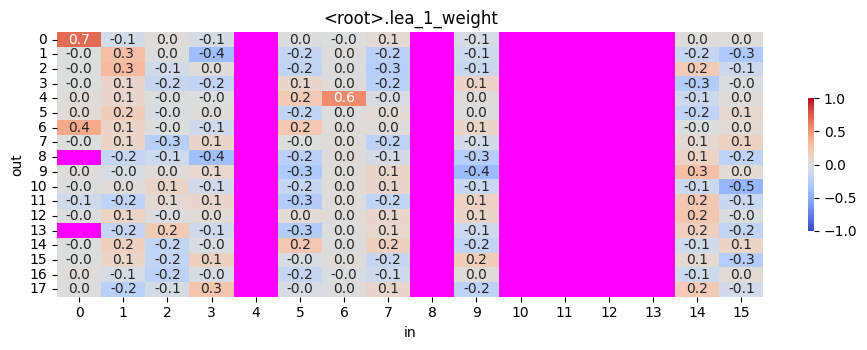

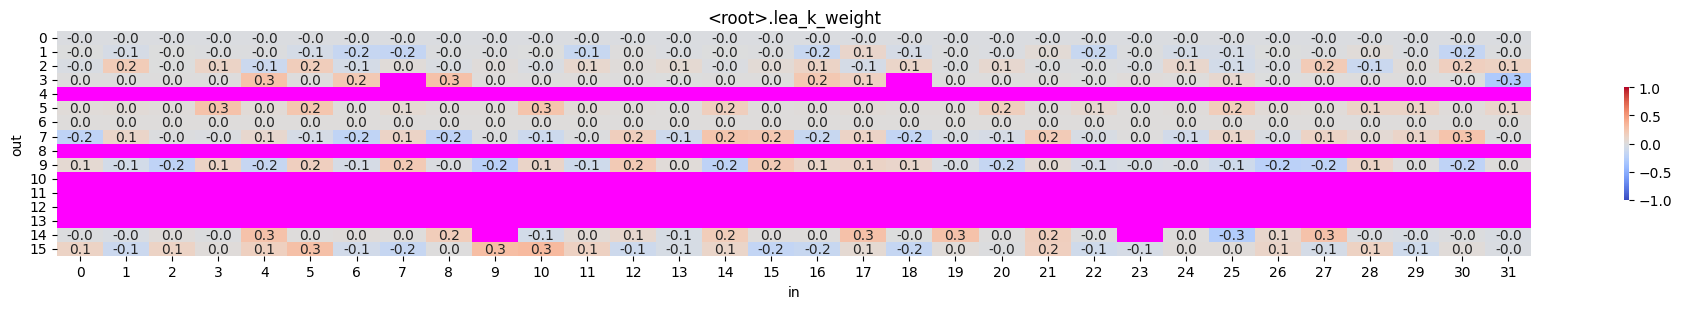

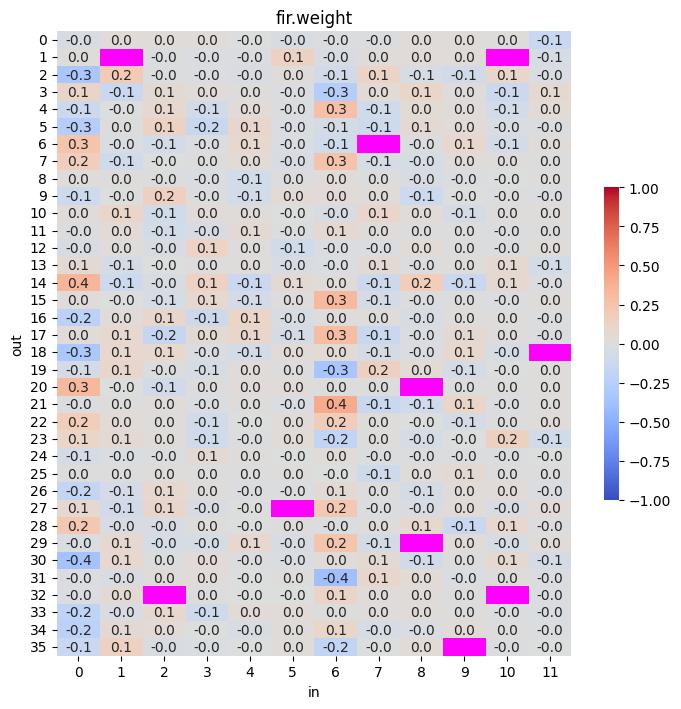

In [ ]:
prunning.log_layerwise_sparsity(pleann_dpd_model)
plotting.plot_weight_heatmaps(pleann_dpd_model, vmin=-1, vmax=1)

LEANN

In [11]:

leann_train_props = {
    "M": M,
    "L1": 6,
    "L2": 64,
    "L3": 8,
    "K": 2,
    "lr": 0.001,
    "epochs": 300,
    "acpr_meter": acpr_meter
}

leann_pipeline = SimplePipeline(container=container, 
                              train_props=leann_train_props, 
                              base_model=LEANN,
                              pa_model=pa_model)



In [ ]:

leann_stats = leann_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

leann_agg_stats = metrics.summarize_statistics(leann_stats)

leann_results = leann_pipeline.get_results()

leann_count = leann_results["ilc"]["count_params"]

final_leann_stats = {
        "Model": "LEANN",
        "Params": leann_count,
        "FLOPs": leann_results["ilc"]["count_flops"],
        "NMSE (dB)": round(leann_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(leann_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(leann_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_leann_stats)


=== Run 1/5 ===
Run ILC
count_params: 1948
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.17273933, val_loss: 0.01094809, val_NMSE: -19.49, lr: 0.001
Epoch 0001 — train_loss: 0.00779785, val_loss: 0.00532575, val_NMSE: -22.62, lr: 0.001
Epoch 0002 — train_loss: 0.00440050, val_loss: 0.00344824, val_NMSE: -24.51, lr: 0.001
Epoch 0003 — train_loss: 0.00295053, val_loss: 0.00228547, val_NMSE: -26.29, lr: 0.001
Epoch 0004 — train_loss: 0.00199116, val_loss: 0.00161272, val_NMSE: -27.81, lr: 0.001
Epoch 0005 — train_loss: 0.00138007, val_loss: 0.00102868, val_NMSE: -29.77, lr: 0.001
Epoch 0006 — train_loss: 0.00093440, val_loss: 0.00075115, val_NMSE: -31.13, lr: 0.001
Epoch 0007 — train_loss: 0.00071716, val_loss: 0.00055952, val_NMSE: -32.42, lr: 0.001
Epoch 0008 — train_loss: 0.00055606, val_loss: 0.00044288, val_NMSE: -33.45, lr: 0.001
Epoch 0009 — train_loss: 0.00044130, val_loss: 0.00031165, val_NMSE: -34.98, lr: 0.001
Epoch 0010 — train_loss: 0

RTDTNN

In [13]:
'''
"d_model": 8,
"n_heads": 2,
"d_ff": 16,
"n_fc": 14,
"num_blocks": 2,

nmse: -45
'''


rtdtnn_train_props = {
    "M": M,
    "P": P,
    "d_in": P+2,
    "d_model": 14,
    "n_heads": 2,
    "d_ff": 12,
    "n_fc": 8,
    "num_blocks": 1,
    "lr": 0.001,
    "epochs": 400,
    "acpr_meter": acpr_meter
}

rtdtnn_pipeline = SimplePipeline(container=container, 
                              train_props=rtdtnn_train_props, 
                              base_model=RTDTNN,
                              pa_model=pa_model)


In [ ]:

rtdtnn_stats = rtdtnn_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

rtdtnn_agg_stats = metrics.summarize_statistics(rtdtnn_stats)

rtdtnn_results = rtdtnn_pipeline.get_results()

rtdtnn_count = rtdtnn_results["ilc"]["count_params"]

final_rtdtnn_stats = {
        "Model": "RTDTNN",
        "Params": rtdtnn_count,
        "FLOPs": rtdtnn_results["ilc"]["count_flops"],
        "NMSE (dB)": round(rtdtnn_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(rtdtnn_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(rtdtnn_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_rtdtnn_stats)


=== Run 1/5 ===
Run ILC
count_params: 2050
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.28766938, val_loss: 0.03660828, val_NMSE: -14.27, lr: 0.001
Epoch 0001 — train_loss: 0.02069234, val_loss: 0.00926520, val_NMSE: -20.26, lr: 0.001
Epoch 0002 — train_loss: 0.00824427, val_loss: 0.00601579, val_NMSE: -22.15, lr: 0.001
Epoch 0003 — train_loss: 0.00541495, val_loss: 0.00391453, val_NMSE: -24.03, lr: 0.001
Epoch 0004 — train_loss: 0.00381477, val_loss: 0.00265688, val_NMSE: -25.71, lr: 0.001
Epoch 0005 — train_loss: 0.00310595, val_loss: 0.00284372, val_NMSE: -25.38, lr: 0.001
Epoch 0006 — train_loss: 0.00243593, val_loss: 0.00163498, val_NMSE: -27.84, lr: 0.001
Epoch 0007 — train_loss: 0.00200163, val_loss: 0.00137437, val_NMSE: -28.58, lr: 0.001
Epoch 0008 — train_loss: 0.00158014, val_loss: 0.00105164, val_NMSE: -29.77, lr: 0.001
Epoch 0009 — train_loss: 0.00146025, val_loss: 0.00091208, val_NMSE: -30.41, lr: 0.001
Epoch 0010 — train_loss: 0

GRU

In [8]:
gru_train_props = {
    "hidden_size": 24, 
    "num_layers": 1,
    "bidirectional": False,
    "lr": 0.01,
    "epochs": 300,
    "acpr_meter": acpr_meter
}

gru_pipeline = SimplePipeline(container=container, 
                              train_props=gru_train_props, 
                              base_model=GRU,
                              pa_model=pa_model)


In [ ]:

gru_stats = gru_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

gru_agg_stats = metrics.summarize_statistics(gru_stats)

gru_results = gru_pipeline.get_results()

gru_count = gru_results["ilc"]["count_params"]

final_gru_stats = {
        "Model": "GRU",
        "Params": gru_count,
        "FLOPs": gru_results["ilc"]["count_flops"],
        "NMSE (dB)": round(gru_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(gru_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(gru_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_gru_stats)


=== Run 1/5 ===
Run ILC
count_params: 2066
Epoch [0/200], Loss: 0.004443641286343336
Epoch [100/200], Loss: 8.294723130575221e-08
Epoch [199/200], Loss: 2.2939243837782897e-09
Выполнение заняло: 0:01:41
Epoch [0/200], Loss: 0.004412407521158457
Epoch [100/200], Loss: 8.252550998122388e-08
Epoch [199/200], Loss: 5.0308555064881855e-12
Выполнение заняло: 0:00:27
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.03436075, val_loss: 0.00083485, val_NMSE: -30.22, lr: 0.01
Epoch 0001 — train_loss: 0.00146287, val_loss: 0.00033601, val_NMSE: -34.17, lr: 0.01
Epoch 0002 — train_loss: 0.00104116, val_loss: 0.00048323, val_NMSE: -32.59, lr: 0.01
Epoch 0003 — train_loss: 0.00086928, val_loss: 0.00032459, val_NMSE: -34.32, lr: 0.01
Epoch 0004 — train_loss: 0.00078739, val_loss: 0.00021388, val_NMSE: -36.13, lr: 0.01
Epoch 0005 — train_loss: 0.00071985, val_loss: 0.00015534, val_NMSE: -37.52, lr: 0.01
Epoch 0006 — train_loss: 0.00068238, val_loss: 0.00011632, v

LSTM

In [10]:
lstm_train_props = {
    "hidden_size": 20, 
    "num_layers": 1,
    "bidirectional": False,
    "lr": 0.01,
    "epochs": 200,
    "acpr_meter": acpr_meter
}

lstm_pipeline = SimplePipeline(container=container, 
                              train_props=lstm_train_props, 
                              base_model=LSTM,
                              pa_model=pa_model)


In [ ]:

lstm_stats = lstm_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

lstm_agg_stats = metrics.summarize_statistics(lstm_stats)

lstm_results = lstm_pipeline.get_results()

lstm_count = lstm_results["ilc"]["count_params"]

final_lstm_stats = {
        "Model": "LSTM",
        "Params": lstm_count,
        "FLOPs": lstm_results["ilc"]["count_flops"],
        "NMSE (dB)": round(lstm_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(lstm_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(lstm_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_lstm_stats)


=== Run 1/5 ===
Run ILC
count_params: 1962
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.04606683, val_loss: 0.00099525, val_NMSE: -29.45, lr: 0.01
Epoch 0001 — train_loss: 0.00179736, val_loss: 0.00049844, val_NMSE: -32.46, lr: 0.01
Epoch 0002 — train_loss: 0.00132922, val_loss: 0.00041924, val_NMSE: -33.21, lr: 0.01
Epoch 0003 — train_loss: 0.00111268, val_loss: 0.00033137, val_NMSE: -34.23, lr: 0.01
Epoch 0004 — train_loss: 0.00095451, val_loss: 0.00034816, val_NMSE: -34.02, lr: 0.01
Epoch 0005 — train_loss: 0.00086616, val_loss: 0.00026101, val_NMSE: -35.27, lr: 0.01
Epoch 0006 — train_loss: 0.00079391, val_loss: 0.00022592, val_NMSE: -35.89, lr: 0.01
Epoch 0007 — train_loss: 0.00076353, val_loss: 0.00026998, val_NMSE: -35.12, lr: 0.01
Epoch 0008 — train_loss: 0.00072729, val_loss: 0.00023371, val_NMSE: -35.75, lr: 0.01
Epoch 0009 — train_loss: 0.00071577, val_loss: 0.00023811, val_NMSE: -35.67, lr: 0.01
Epoch 0010 — train_loss: 0.00066980,

Metrics

In [18]:
final_gmp_stats = {'Model': 'GMP', 'Params': 2176, "MACs": 5981, 'NMSE (dB)': np.float64(-45.68), 'ACPR left (dB)': np.float64(-57.71), 'ACPR right (dB)': np.float64(-57.26)}
final_gru_stats = {'Model': 'GRU', 'Params': 2066, "MACs": 1920, 'NMSE (dB)': np.float64(-51.21), 'ACPR left (dB)': np.float64(-62.65), 'ACPR right (dB)': np.float64(-63.33)}
final_kpgru_stats = {'Model': 'KPGRU', 'Params': 2046, "MACs": 2101, 'NMSE (dB)': np.float64(-52.56), 'ACPR left (dB)': np.float64(-64.79), 'ACPR right (dB)': np.float64(-66.22)}
final_kplstm_stats = {'Model': 'KPLSTM', 'Params': 2018, "MACs": 2069, 'NMSE (dB)': np.float64(-49.72), 'ACPR left (dB)': np.float64(-63.14), 'ACPR right (dB)': np.float64(-64.2)}
final_kptcn_stats = {'Model': 'KPTCN', 'Params': 2036, "MACs": 2129, 'NMSE (dB)': np.float64(-54.37), 'ACPR left (dB)': np.float64(-68.1), 'ACPR right (dB)': np.float64(-68.65)}
final_lstm_stats = {'Model': 'LSTM', 'Params': 1962, "MACs": 1800, 'NMSE (dB)': np.float64(-48.16), 'ACPR left (dB)': np.float64(-60.39), 'ACPR right (dB)': np.float64(-60.46)}
final_tcn_stats = {'Model': 'TCN', 'Params': 2016, "MACs": 1920, 'NMSE (dB)': np.float64(-48.02), 'ACPR left (dB)': np.float64(-61.92), 'ACPR right (dB)': np.float64(-61.55)}
final_rtdtnn_stats = {'Model': 'RTDTNN', 'Params': 2050, "MACs": 8836, 'NMSE (dB)': np.float64(-46.08), 'ACPR left (dB)': np.float64(-57.1), 'ACPR right (dB)': np.float64(-58.13)}
final_leann_stats = {'Model': 'LEANN', 'Params': 1948, "MACs": 4430, 'NMSE (dB)': np.float64(-48.76), 'ACPR left (dB)': np.float64(-62.02), 'ACPR right (dB)': np.float64(-62.9)}

# final_pleann_stats

In [20]:

ilc_results = [
    final_gmp_stats, 
    final_gru_stats, 
    final_kpgru_stats, 
    final_kplstm_stats,
    final_kptcn_stats,
    final_lstm_stats,
    final_tcn_stats,
    final_rtdtnn_stats,
    final_leann_stats,
    # final_pleann_stats,
    ]

df = pd.DataFrame(ilc_results)
df = df.sort_values(by=["NMSE (dB)", "ACPR left (dB)", "ACPR right (dB)"], ascending=[True, True, True]).reset_index(drop=True)

print(df)

df.to_excel("model_metrics.xlsx", index=False)

    Model  Params  MACs  NMSE (dB)  ACPR left (dB)  ACPR right (dB)
0   KPTCN    2036  2129     -54.37          -68.10           -68.65
1   KPGRU    2046  2101     -52.56          -64.79           -66.22
2     GRU    2066  1920     -51.21          -62.65           -63.33
3  KPLSTM    2018  2069     -49.72          -63.14           -64.20
4   LEANN    1948  4430     -48.76          -62.02           -62.90
5    LSTM    1962  1800     -48.16          -60.39           -60.46
6     TCN    2016  1920     -48.02          -61.92           -61.55
7  RTDTNN    2050  8836     -46.08          -57.10           -58.13
8     GMP    2176  5981     -45.68          -57.71           -57.26


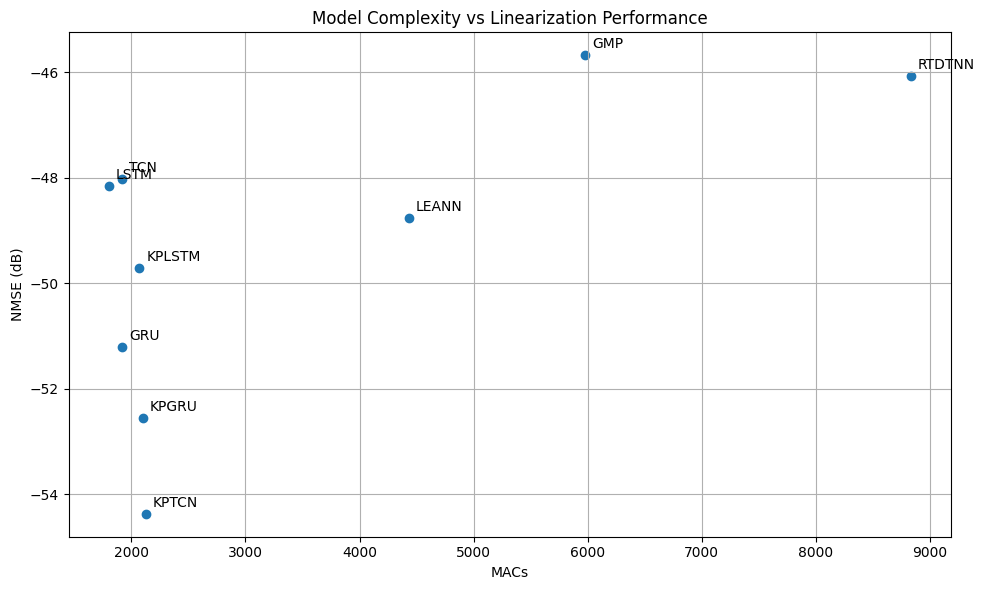

In [21]:
plt.figure(figsize=(10, 6))

# scatter
plt.scatter(
    df["MACs"],
    df["NMSE (dB)"]
)

# labels
for _, row in df.iterrows():
    plt.annotate(
        row["Model"],
        (row["MACs"], row["NMSE (dB)"]),
        textcoords="offset points",
        xytext=(5, 5)
    )

plt.xlabel("MACs")
plt.ylabel("NMSE (dB)")
plt.title("Model Complexity vs Linearization Performance")

plt.grid(True)

plt.tight_layout()
plt.show()